In [29]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import accuracy_score,confusion_matrix

In [76]:
df=pd.read_csv("Data_Train.csv")

In [31]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR ? DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU ? IXR ? BBI ? BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL ? LKO ? BOM ? COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU ? NAG ? BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR ? NAG ? DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [32]:
df.tail()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU ? BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU ? BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR ? DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR ? DEL,11:30,14:10,2h 40m,non-stop,No info,12648
10682,Air India,9/05/2019,Delhi,Cochin,DEL ? GOI ? BOM ? COK,10:55,19:15,8h 20m,2 stops,No info,11753


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [34]:
df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [35]:
df.shape

(10683, 11)

In [36]:
df.size

117513

In [37]:
df.isnull()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
10678,False,False,False,False,False,False,False,False,False,False,False
10679,False,False,False,False,False,False,False,False,False,False,False
10680,False,False,False,False,False,False,False,False,False,False,False
10681,False,False,False,False,False,False,False,False,False,False,False


In [38]:
df.isnull().sum()

,0
Airline,0
Date_of_Journey,0
Source,0
Destination,0
Route,1
Dep_Time,0
Arrival_Time,0
Duration,0
Total_Stops,1
Additional_Info,0


In [39]:
import missingno as msno


<function matplotlib.pyplot.show(close=None, block=None)>

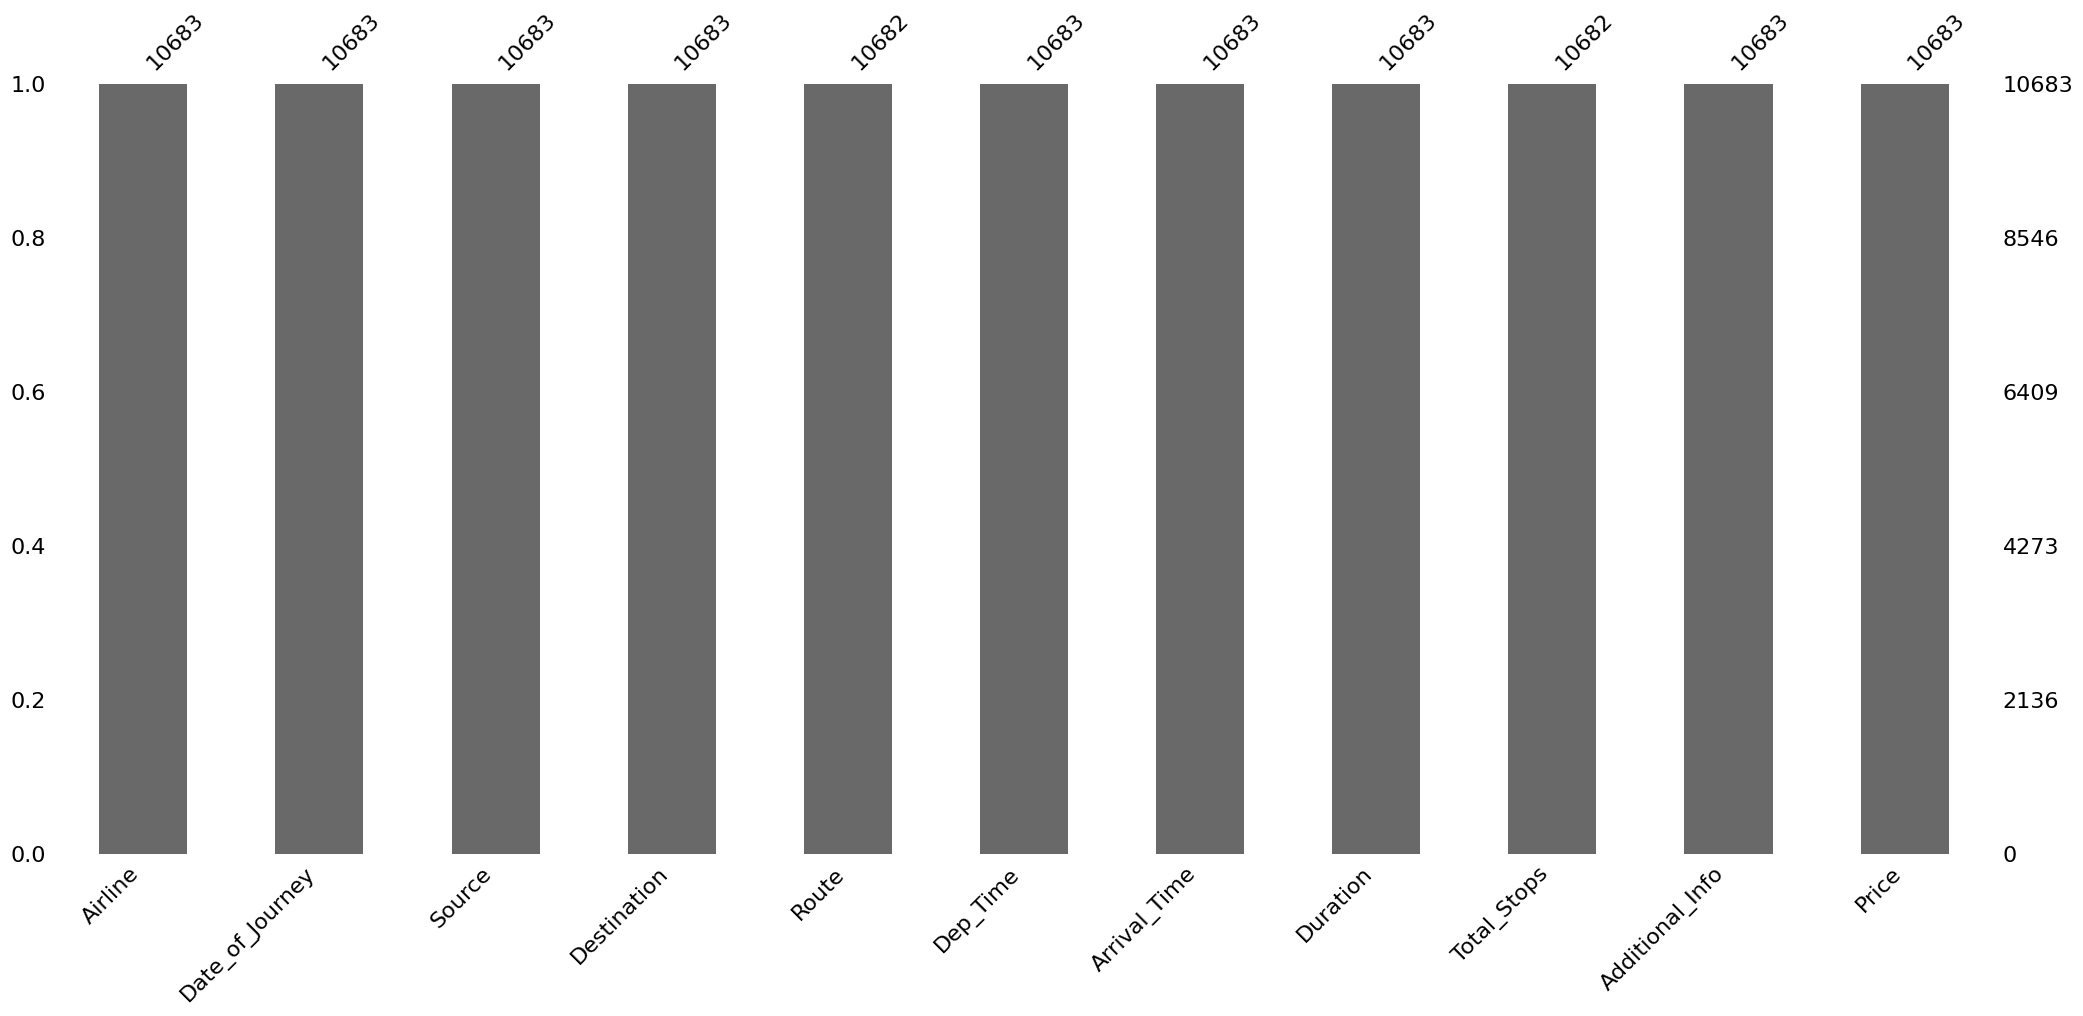

In [40]:
msno.bar(df)
plt.show

In [41]:
df.dropna(inplace=True)

In [42]:
df.isnull().sum()

,0
Airline,0
Date_of_Journey,0
Source,0
Destination,0
Route,0
Dep_Time,0
Arrival_Time,0
Duration,0
Total_Stops,0
Additional_Info,0


In [43]:
df.dtypes

,0
Airline,object
Date_of_Journey,object
Source,object
Destination,object
Route,object
Dep_Time,object
Arrival_Time,object
Duration,object
Total_Stops,object
Additional_Info,object


In [44]:
df.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='object')

In [45]:
def change_into_datetime(col):
    df[col] = pd.to_datetime(df[col])

In [46]:
df.dtypes

,0
Airline,object
Date_of_Journey,object
Source,object
Destination,object
Route,object
Dep_Time,object
Arrival_Time,object
Duration,object
Total_Stops,object
Additional_Info,object


In [47]:
df.drop('Date_of_Journey', axis=1, inplace=True)

In [48]:
df.head(10)

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,Banglore,New Delhi,BLR ? DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,Kolkata,Banglore,CCU ? IXR ? BBI ? BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,Delhi,Cochin,DEL ? LKO ? BOM ? COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,Kolkata,Banglore,CCU ? NAG ? BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,Banglore,New Delhi,BLR ? NAG ? DEL,16:50,21:35,4h 45m,1 stop,No info,13302
5,SpiceJet,Kolkata,Banglore,CCU ? BLR,09:00,11:25,2h 25m,non-stop,No info,3873
6,Jet Airways,Banglore,New Delhi,BLR ? BOM ? DEL,18:55,10:25 13 Mar,15h 30m,1 stop,In-flight meal not included,11087
7,Jet Airways,Banglore,New Delhi,BLR ? BOM ? DEL,08:00,05:05 02 Mar,21h 5m,1 stop,No info,22270
8,Jet Airways,Banglore,New Delhi,BLR ? BOM ? DEL,08:55,10:25 13 Mar,25h 30m,1 stop,In-flight meal not included,11087
9,Multiple carriers,Delhi,Cochin,DEL ? BOM ? COK,11:25,19:15,7h 50m,1 stop,No info,8625


In [49]:
df = pd.DataFrame({'Dep_Time': ['22:15', '10:30', '05:45']})

# Convert to datetime
df['Dep_Time'] = pd.to_datetime(df['Dep_Time'], format='%H:%M')

# Function definitions
def extract_hour(df, col):
    df[col + '_hour'] = df[col].dt.hour

def extract_min(df, col):
    df[col + '_minute'] = df[col].dt.minute

def drop_col(df, col):
    df.drop(columns=[col], inplace=True)

In [50]:
extract_hour(df,'Dep_Time')
extract_min(df,'Dep_Time')
drop_col(df,'Dep_Time')

In [51]:

print(df)


   Dep_Time_hour  Dep_Time_minute
0             22               15
1             10               30
2              5               45


In [52]:
df = pd.DataFrame({
    'Arrival_Time': ['01:50', '13:15', '21:35', '04:00']
})

# Convert 'Arrival_Time' to datetime
df['Arrival_Time'] = pd.to_datetime(df['Arrival_Time'], format='%H:%M')

# Define function to extract hour
def extract_hour(df, col):
    df[col + '_hour'] = df[col].dt.hour

# Define function to extract minute
def extract_min(df, col):
    df[col + '_minute'] = df[col].dt.minute

# Define function to drop column
def drop_col(df, col):
    df.drop(columns=[col], inplace=True)

In [53]:
extract_hour(df,'Arrival_Time')
extract_min(df,'Arrival_Time')
drop_col(df,'Arrival_Time')

In [54]:
print(df)


   Arrival_Time_hour  Arrival_Time_minute
0                  1                   50
1                 13                   15
2                 21                   35
3                  4                    0


In [55]:
df.head(10)

,Arrival_Time_hour,Arrival_Time_minute
0,1,50
1,13,15
2,21,35
3,4,0


In [56]:
def hour(x):
    return x.split(' ')[0][0:-1]

def minutes(x):
    parts = x.split(' ')
    if len(parts) > 1:
        return parts[1][0:-1]
    else:
        return '0' # Or '00' depending on desired format

In [57]:
df = pd.DataFrame({'Duration': ['2h 50m', '5h', '30m', '1h 5m', '3h']})

In [58]:
def hour(duration):
    if 'h' in duration:
        return int(duration.split('h')[0])
    else:
        return 0


In [59]:
df['dur_hour'] = df['Duration'].apply(hour)

In [60]:
print(df)

  Duration  dur_hour
0   2h 50m         2
1       5h         5
2      30m         0
3    1h 5m         1
4       3h         3


In [61]:
df['dur_min']=df['Duration'].apply(minutes)

In [62]:
df.head(10)

,Duration,dur_hour,dur_min
0,2h 50m,2,50
1,5h,5,0
2,30m,0,0
3,1h 5m,1,5
4,3h,3,0


In [63]:
drop_col(df,'Duration')

In [64]:
df.dtypes

,0
dur_hour,int64
dur_min,object


In [65]:
df['dur_hour'] = df['dur_hour'].astype(int)
df['dur_min'] = df['dur_min'].astype(int)

In [66]:
df.dtypes

,0
dur_hour,int64
dur_min,int64


In [67]:
column=[column for column in df.columns if df[column].dtype=='object']
column

[]

In [68]:
continuous_col =[column for column in df.columns if df[column].dtype!='object']
continuous_col

['dur_hour', 'dur_min']

In [81]:
categorical = df.select_dtypes(include='object').copy()

In [70]:
categorical.head()

""
0
1
2
3
4


In [71]:
df = pd.DataFrame({
    'Airline': ['IndiGo', 'Air India', 'IndiGo', 'SpiceJet', 'IndiGo', 'Air India']
})

In [82]:
# This cell is no longer needed as categorical is created correctly above.
# categorical = df.select_dtypes(include='object')

In [73]:
print(categorical['Airline'].value_counts())

Airline
IndiGo       3
Air India    2
SpiceJet     1
Name: count, dtype: int64


In [74]:
print(df.columns.tolist())

['Airline']


In [77]:
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df['Airline'] = df['Airline'].astype(str)


<Axes: xlabel='Airline', ylabel='Price'>

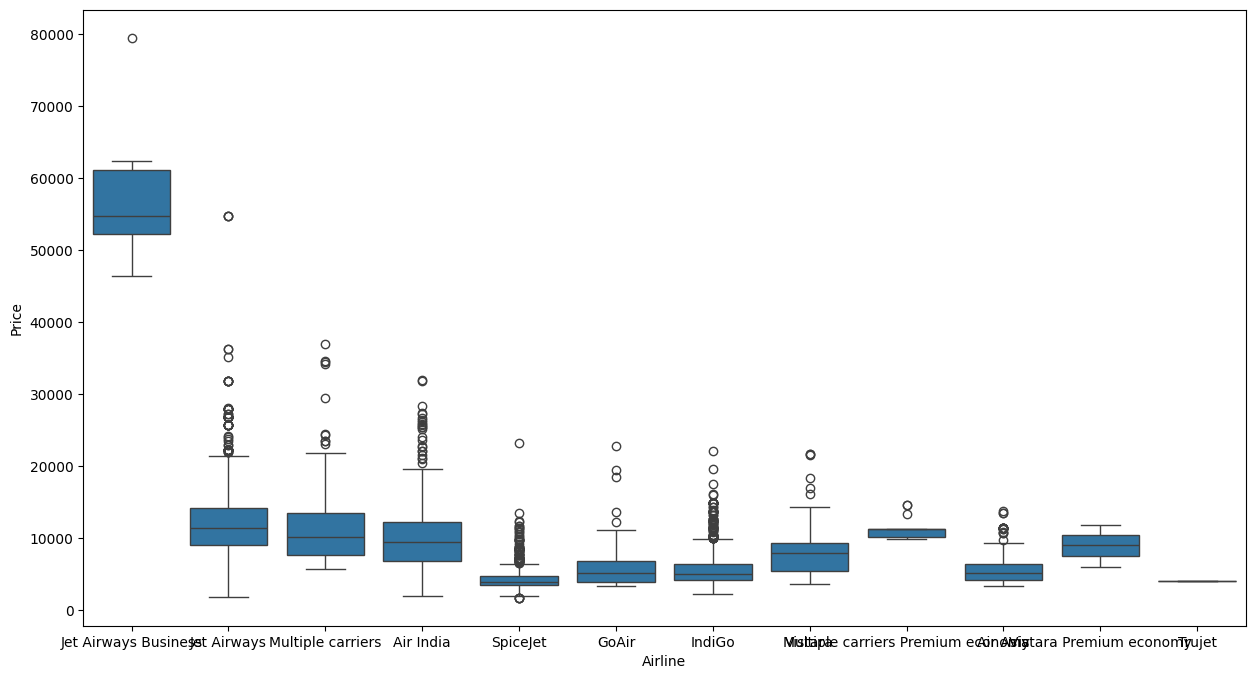

In [84]:
plt.figure(figsize=(15,8))
sns.boxplot(x='Airline',y='Price',data=df.sort_values('Price',ascending=False))

<Axes: xlabel='Total_Stops', ylabel='Price'>

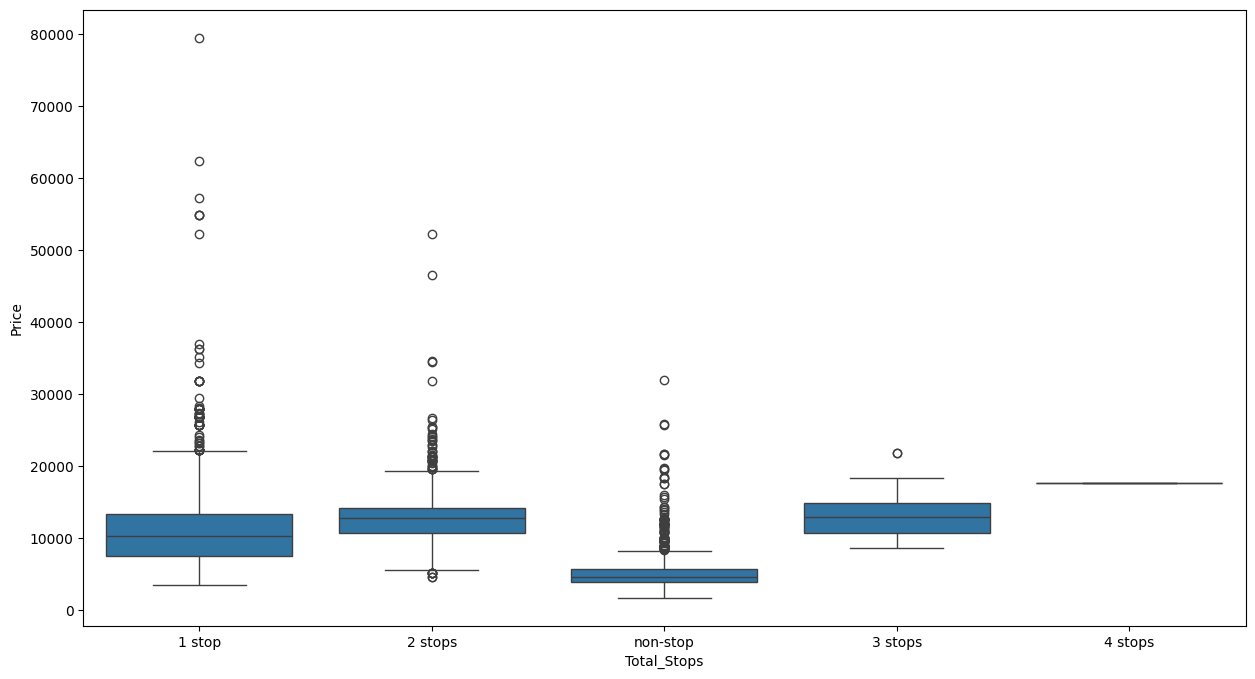

In [78]:
plt.figure(figsize=(15,8))
sns.boxplot(x='Total_Stops',y='Price',data=df.sort_values('Price',ascending=False))

<Figure size 1500x1500 with 0 Axes>

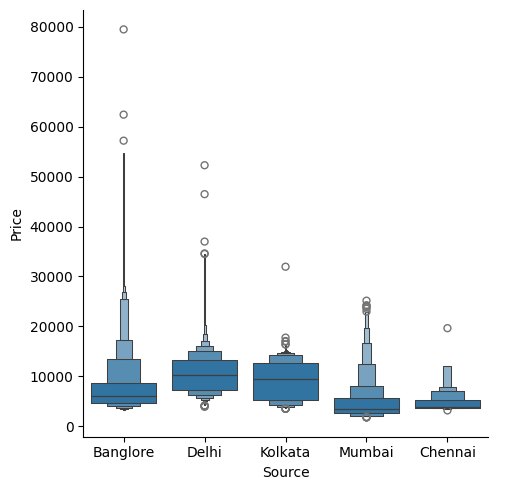

In [79]:
plt.figure(figsize=(15,15))
sns.catplot(x='Source',y='Price',data=df.sort_values('Price',ascending=False),kind='boxen')

In [91]:
source=pd.get_dummies(categorical['Source'],drop_first=True).astype(int)
source.head()

,Chennai,Delhi,Kolkata,Mumbai
0,0,0,0,0
1,0,0,1,0
2,0,1,0,0
3,0,0,1,0
4,0,0,0,0


In [86]:
categorical['Destination'].value_counts()

,count
Destination,
Cochin,4537
Banglore,2871
Delhi,1265
New Delhi,932
Hyderabad,697
Kolkata,381


<Axes: xlabel='Destination', ylabel='Price'>

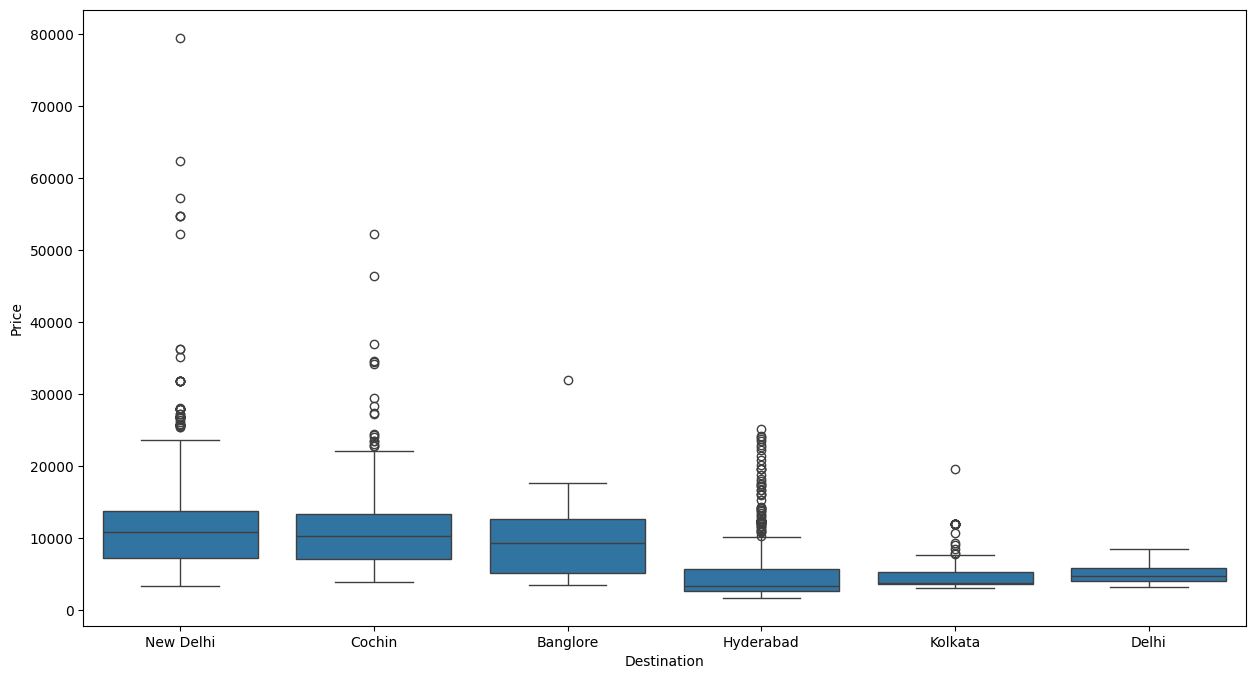

In [87]:
plt.figure(figsize=(15,8))
sns.boxplot(x='Destination',y='Price',data=df.sort_values('Price',ascending=False))

In [88]:
for i in categorical.columns:
    print('{} has total {} categories'.format(i,len(categorical[i].value_counts())))

Airline has total 12 categories
Date_of_Journey has total 44 categories
Source has total 5 categories
Destination has total 6 categories
Route has total 128 categories
Dep_Time has total 222 categories
Arrival_Time has total 1343 categories
Duration has total 368 categories
Total_Stops has total 5 categories
Additional_Info has total 10 categories


In [93]:
airline = pd.get_dummies(categorical['Airline'], drop_first=True).astype(int)
airline.head()

,Air India,GoAir,IndiGo,Jet Airways,Jet Airways Business,Multiple carriers,Multiple carriers Premium economy,SpiceJet,Trujet,Vistara,Vistara Premium economy
0,0,0,1,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,1,0,0,0,0,0,0,0
3,0,0,1,0,0,0,0,0,0,0,0
4,0,0,1,0,0,0,0,0,0,0,0


<Axes: xlabel='Arrival_Time_hour', ylabel='Price'>

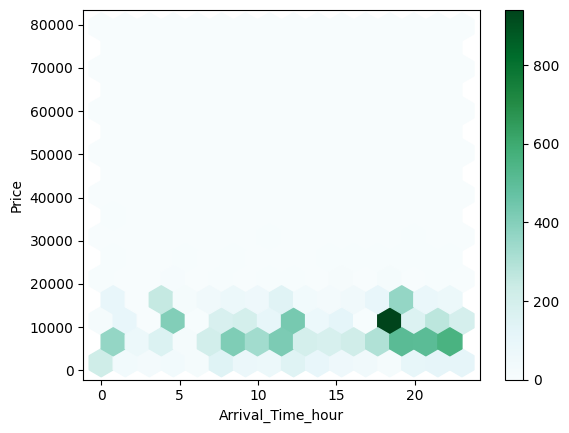

In [102]:
final_df.plot.hexbin(x='Arrival_Time_hour',y='Price',gridsize=15)

In [103]:
from sklearn.preprocessing import LabelEncoder

In [104]:
encoder = LabelEncoder()

In [105]:
drop_col(categorical,'Additional_Info')

In [106]:
categorical['Total_Stops'].unique()

array(['non-stop', '2 stops', '1 stop', '3 stops', nan, '4 stops'],
      dtype=object)

In [107]:
dict={'non-stop':0, '2 stops':2, '1 stop':1, '3 stops':3, '4 stops':4}
categorical['Total_Stops']=categorical['Total_Stops'].map(dict)

In [108]:
categorical['Total_Stops']

,Total_Stops
0,0.0
1,2.0
2,2.0
3,1.0
4,1.0
...,...
10678,0.0
10679,0.0
10680,0.0
10681,0.0


In [173]:
destination = pd.get_dummies(categorical['Destination'], drop_first=True).astype(int)
destination.head()

,Cochin,Delhi,Hyderabad,Kolkata,New Delhi
0,0,0,0,0,1
1,0,0,0,0,0
2,1,0,0,0,0
3,0,0,0,0,0
4,0,0,0,0,1


In [98]:
categorical['Dep_Time_hour'] = pd.to_datetime(categorical['Dep_Time']).dt.hour
categorical['Dep_Time_minute'] = pd.to_datetime(categorical['Dep_Time']).dt.minute
categorical['Arrival_Time_hour'] = pd.to_datetime(categorical['Arrival_Time']).dt.hour
categorical['Arrival_Time_minute'] = pd.to_datetime(categorical['Arrival_Time']).dt.minute

/tmp/ipython-input-98-2932396092.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  categorical['Dep_Time_hour'] = pd.to_datetime(categorical['Dep_Time']).dt.hour
/tmp/ipython-input-98-2932396092.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  categorical['Dep_Time_minute'] = pd.to_datetime(categorical['Dep_Time']).dt.minute
/tmp/ipython-input-98-2932396092.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  categorical['Arrival_Time_hour'] = pd.to_datetime(categorical['Arrival_Time']).dt.hour
/tmp/ipython-input-98-2932396092.py:4: UserWarning: Could not infer format, 

In [109]:
# drop_col(categorical,'Source')
# drop_col(categorical,'Destination')
# drop_col(categorical,'Airline')

In [122]:
# Assuming 'airline' and 'destination' DataFrames have been created using pd.get_dummies()
final_df = pd.concat([categorical.drop(columns=['Airline', 'Source', 'Destination', 'Date_of_Journey', 'Route', 'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops']), airline, source, destination, df[['Price']]], axis=1)

In [112]:
final_df.head()

,Airline,Source,Destination,Dep_Time_hour,Dep_Time_minute,Arrival_Time_hour,Arrival_Time_minute,Air India,GoAir,IndiGo,...,Chennai,Delhi,Kolkata,Mumbai,Cochin,Delhi,Hyderabad,Kolkata,New Delhi,Price
0,IndiGo,Banglore,New Delhi,22,20,1,10,0,0,1,...,0,0,0,0,0,0,0,0,1,3897
1,Air India,Kolkata,Banglore,5,50,13,15,1,0,0,...,0,0,1,0,0,0,0,0,0,7662
2,Jet Airways,Delhi,Cochin,9,25,4,25,0,0,0,...,0,1,0,0,1,0,0,0,0,13882
3,IndiGo,Kolkata,Banglore,18,5,23,30,0,0,1,...,0,0,1,0,0,0,0,0,0,6218
4,IndiGo,Banglore,New Delhi,16,50,21,35,0,0,1,...,0,0,0,0,0,0,0,0,1,13302


In [113]:
def plot(data,col):
    fig,(ax1,ax2)=plt.subplots(2,1)
    sns.distplot(data[col],ax=ax1)
    sns.boxplot(data[col],ax=ax2)

/tmp/ipython-input-113-934290806.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data[col],ax=ax1)


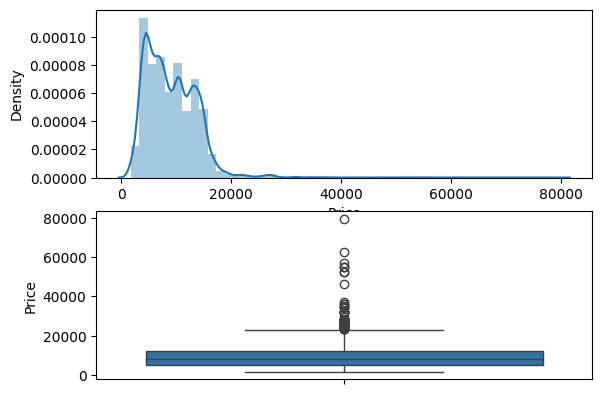

In [114]:
plot(final_df,'Price')

In [115]:
final_df['Price']=np.where(final_df['Price']>=40000,final_df['Price'].median(),final_df['Price'])

/tmp/ipython-input-113-934290806.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data[col],ax=ax1)


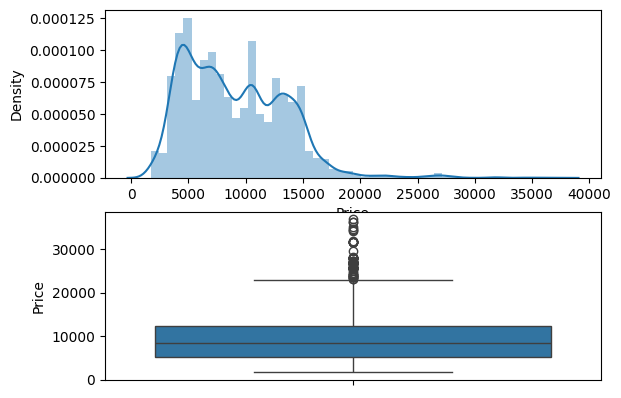

In [116]:
plot(final_df,'Price')

In [117]:
from sklearn.feature_selection import mutual_info_classif

In [126]:
X = final_df.drop(['Price'], axis=1)
y = final_df['Price']

In [127]:
imp = pd.DataFrame(mutual_info_classif(X,y),index=X.columns)
imp

,0
Dep_Time_hour,1.514427
Dep_Time_minute,1.305009
Arrival_Time_hour,1.905638
Arrival_Time_minute,1.582585
Air India,0.695092
GoAir,0.078368
IndiGo,0.627619
Jet Airways,0.860254
Jet Airways Business,0.000755
Multiple carriers,0.505023


# spiliting the dataset

In [128]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=123)

In [129]:
print(x_train)

      Dep_Time_hour  Dep_Time_minute  Arrival_Time_hour  Arrival_Time_minute  \
5955             19               20                 23                   45   
1251              6               30                  8                   15   
265              11               40                  1                   35   
1472             13               15                 14                   45   
495              14                5                  9                   20   
...             ...              ...                ...                  ...   
9785              9                0                 19                   15   
7763             15                5                 20                   20   
5218             21                5                  1                   45   
1346              5               55                 19                   15   
3582             13               15                 14                   45   

      Air India  GoAir  IndiGo  Jet Air

In [130]:
print(y_train)

5955     3809
1251     8586
265      7695
1472     1965
495      9663
        ...  
9785    16108
7763     4649
5218     6937
1346    10493
3582     2017
Name: Price, Length: 8546, dtype: int64


In [131]:
print(x_test)

      Dep_Time_hour  Dep_Time_minute  Arrival_Time_hour  Arrival_Time_minute  \
6041             19               35                 21                   55   
5637             23               55                  2                   45   
9644             13               55                 15                   25   
3159              4                0                  6                   50   
5278             17               45                 20                    5   
...             ...              ...                ...                  ...   
5170             21                0                  2                   15   
1188             17               55                 22                   50   
3388             18               15                 12                   35   
3430             16               30                 19                   50   
7848             11               10                 14                    5   

      Air India  GoAir  IndiGo  Jet Air

In [132]:
print(y_test)

6041     3597
5637     3383
9644     2050
3159     4423
5278     3597
        ...  
5170     6911
1188     4957
3388    10262
3430     8529
7848     7229
Name: Price, Length: 2137, dtype: int64


In [133]:
print(X.shape, x_train.shape, x_test.shape)

(10683, 24) (8546, 24) (2137, 24)


In [134]:
print(y.shape, y_train.shape, y_test.shape)

(10683,) (8546,) (2137,)


In [135]:
scaler= StandardScaler()

In [136]:
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [137]:
print(x_train)

[[ 1.11483413 -0.23428091  1.4104919  ... -0.26150248 -0.19303317
  -0.31355448]
 [-1.13504493  0.29820969 -0.77453477 ... -0.26150248 -0.19303317
  -0.31355448]
 [-0.26970683  0.83070028 -1.79421388 ... -0.26150248 -0.19303317
  -0.31355448]
 ...
 [ 1.46096937 -1.0330168  -1.79421388 ... -0.26150248 -0.19303317
  -0.31355448]
 [-1.30811255  1.62943617  0.82781812 ... -0.26150248 -0.19303317
  -0.31355448]
 [ 0.07642841 -0.5005262   0.0994759  ...  3.82405549 -0.19303317
  -0.31355448]]


In [138]:
print(x_test)

[[ 1.11483413  0.56445498  1.11915501 ... -0.26150248  5.18045689
  -0.31355448]
 [ 1.80710461  1.62943617 -1.64854543 ... -0.26150248 -0.19303317
  -0.31355448]
 [ 0.07642841  1.62943617  0.24514434 ...  3.82405549 -0.19303317
  -0.31355448]
 ...
 [ 0.94176651 -0.5005262  -0.19186099 ... -0.26150248 -0.19303317
  -0.31355448]
 [ 0.59563127  0.29820969  0.82781812 ... -0.26150248 -0.19303317
  -0.31355448]
 [-0.26970683 -0.7667715   0.0994759  ... -0.26150248 -0.19303317
  -0.31355448]]


In [139]:
pip install autoviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.5/67.5 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.3/170.3 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 255.9/255.9 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 590.6/590.6 kB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 85.8 MB/s eta 0:00:00
  Attempting uninstall: xgboost
    Found existing installation: xgboost 2.1.4
    Uninstalling xgboost-2.1.4:
      Successfully uninstalled xgboost-2.1.4


In [140]:
from autoviz.AutoViz_Class import AutoViz_Class

Imported v0.1.905. Please call AutoViz in this sequence:
    AV = AutoViz_Class()
    %matplotlib inline
    dfte = AV.AutoViz(filename, sep=',', depVar='', dfte=None, header=0, verbose=1, lowess=False,
               chart_format='svg',max_rows_analyzed=150000,max_cols_analyzed=30, save_plot_dir=None)


In [141]:
AV=AutoViz_Class()

Shape of your Data Set loaded: (10683, 11)
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#######################################################################################
Classifying variables in data set...
    Number of Numeric Columns =  0
    Number of Integer-Categorical Columns =  1
    Number of String-Categorical Columns =  6
    Number of Factor-Categorical Columns =  0
    Number of String-Boolean Columns =  0
    Number of Numeric-Boolean Columns =  0
    Number of Discrete String Columns =  3
    Number of NLP String Columns =  1
    Number of Date Time Columns =  0
    Number of ID Columns =  0
    Number of Columns to Delete =  0
    11 Predictors classified...
        No variables removed since no ID or low-information variables found in data set
To fix these data quality issues in the dataset, import FixDQ from autoviz...
There are 220 

,Data Type,Missing Values%,Unique Values%,Minimum Value,Maximum Value,DQ Issue
Airline,object,0.000000,0,,,"4 rare categories: ['Multiple carriers Premium economy', 'Jet Airways Business', 'Vistara Premium economy', 'Trujet']. Group them into a single category or drop the categories."
Date_of_Journey,object,0.000000,0,,,12 rare categories: Too many to list. Group them into a single category or drop the categories.
Source,object,0.000000,0,,,No issue
Destination,object,0.000000,0,,,No issue
Route,object,0.009557,1,,,"1 missing values. Impute them with mean, median, mode, or a constant value such as 123., Mixed dtypes: has 2 different data types: object, float,, Possible high cardinality column with 128 unique values: Use hash encoding or text embedding to reduce dimension."
Dep_Time,object,0.000000,2,,,Possible high cardinality column with 222 unique values: Use hash encoding or text embedding to reduce dimension.
Arrival_Time,object,0.000000,12,,,No issue
Duration,object,0.000000,3,,,Possible high cardinality column with 368 unique values: Use hash encoding or text embedding to reduce dimension.
Total_Stops,object,0.009557,0,,,"1 missing values. Impute them with mean, median, mode, or a constant value such as 123., 2 rare categories: ['3 stops', '4 stops']. Group them into a single category or drop the categories., Mixed dtypes: has 2 different data types: object, float,"
Additional_Info,object,0.000000,0,,,"7 rare categories: ['1 Long layover', 'Change airports', 'Business class', 'No Info', '1 Short layover', 'Red-eye flight', '2 Long layover']. Group them into a single category or drop the categories."


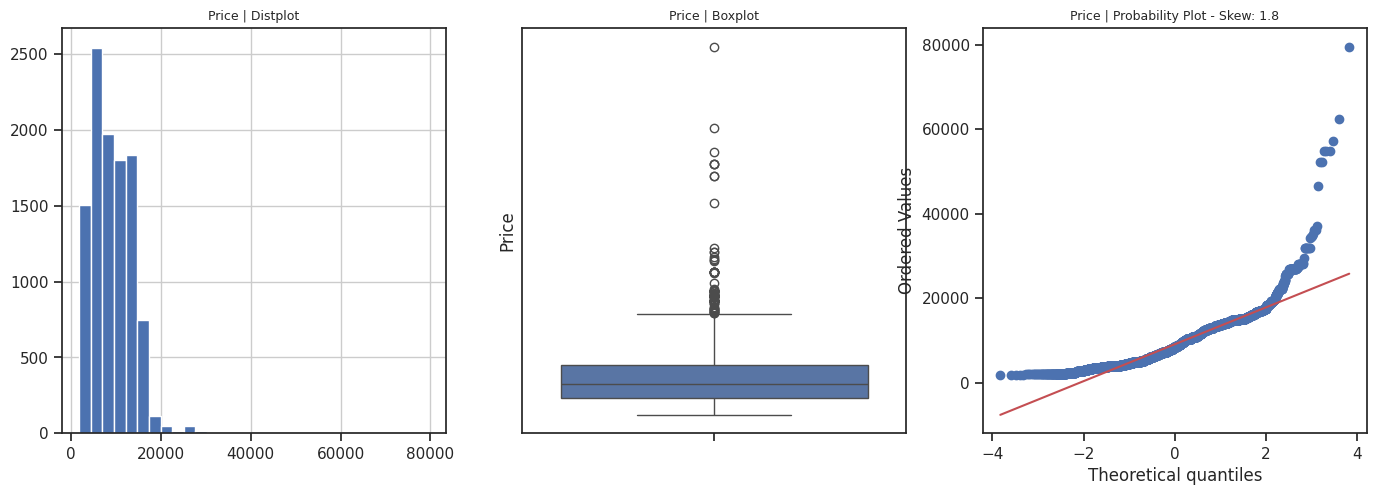

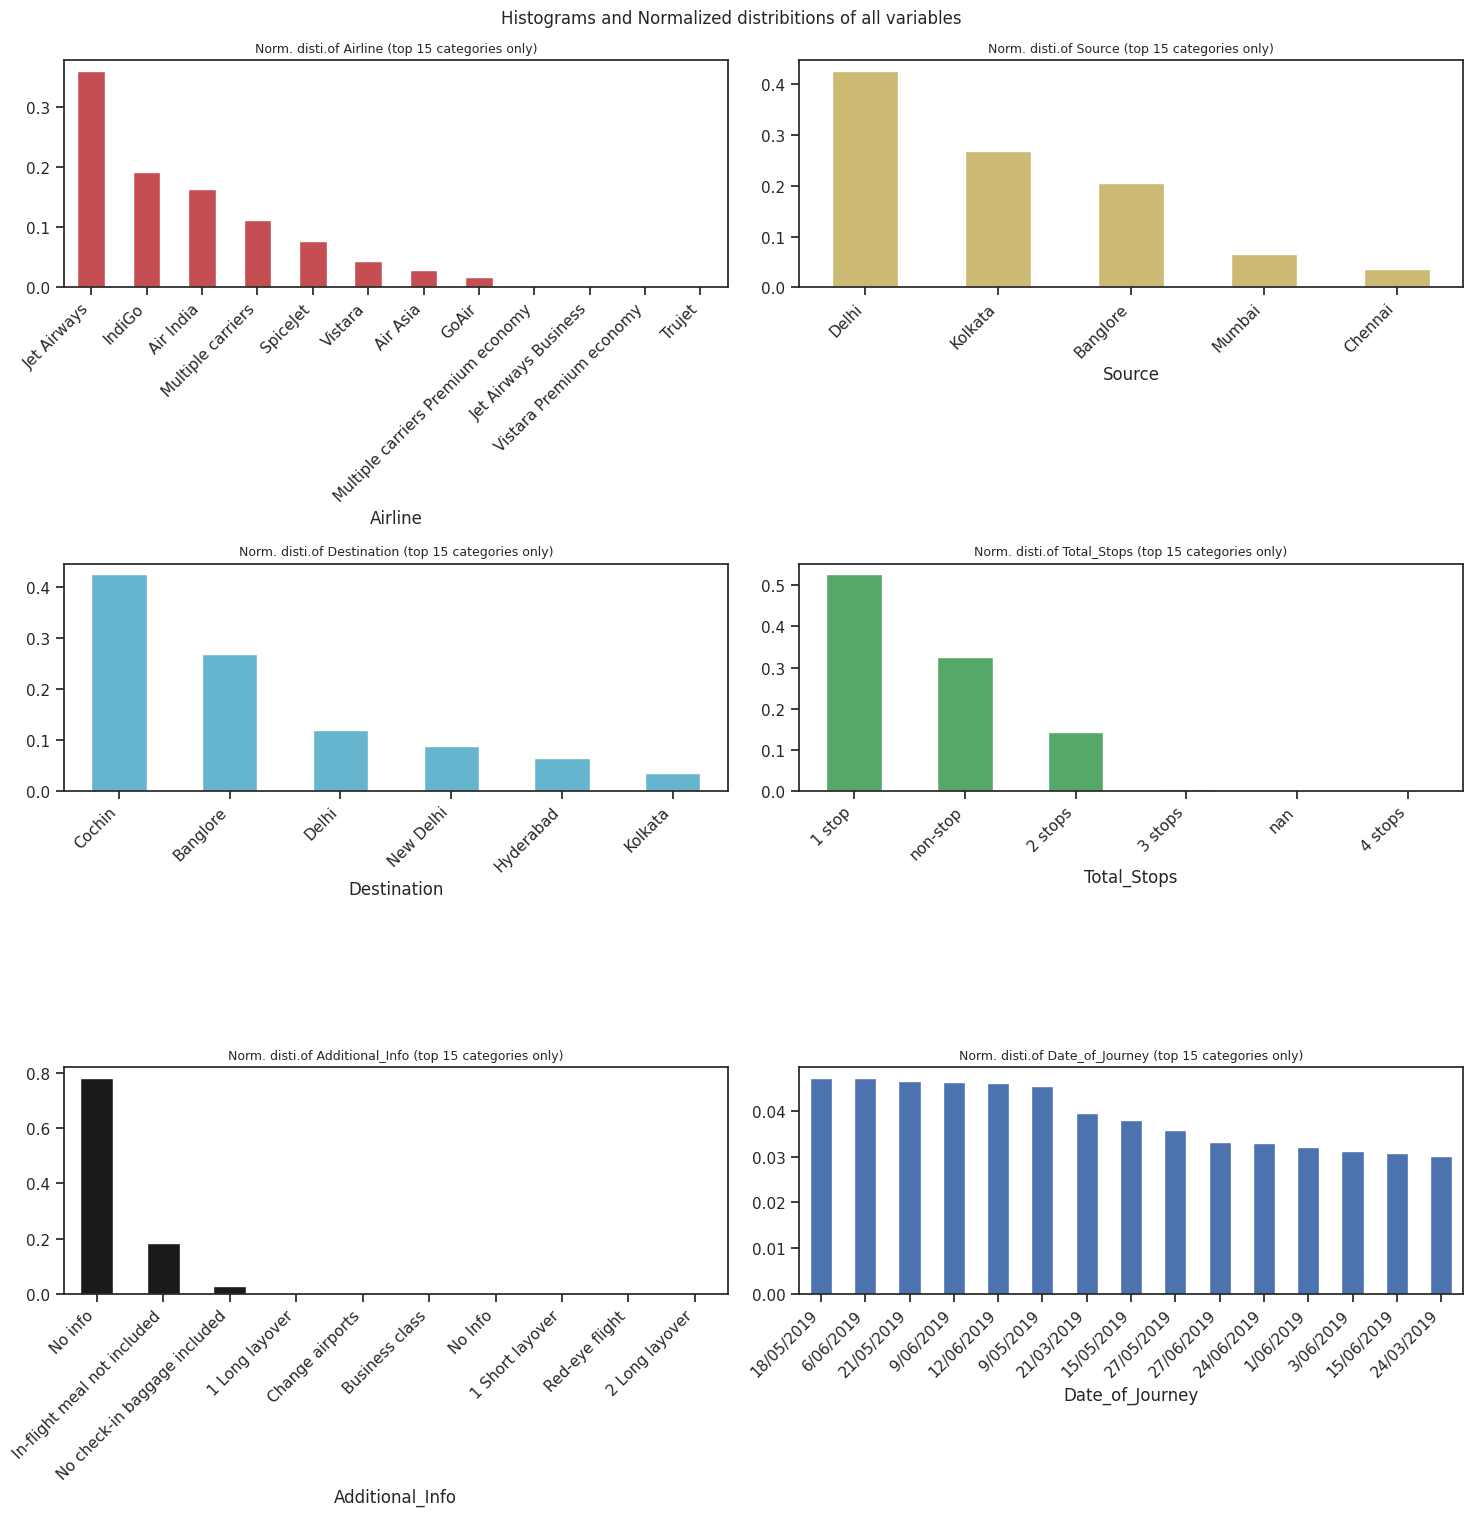

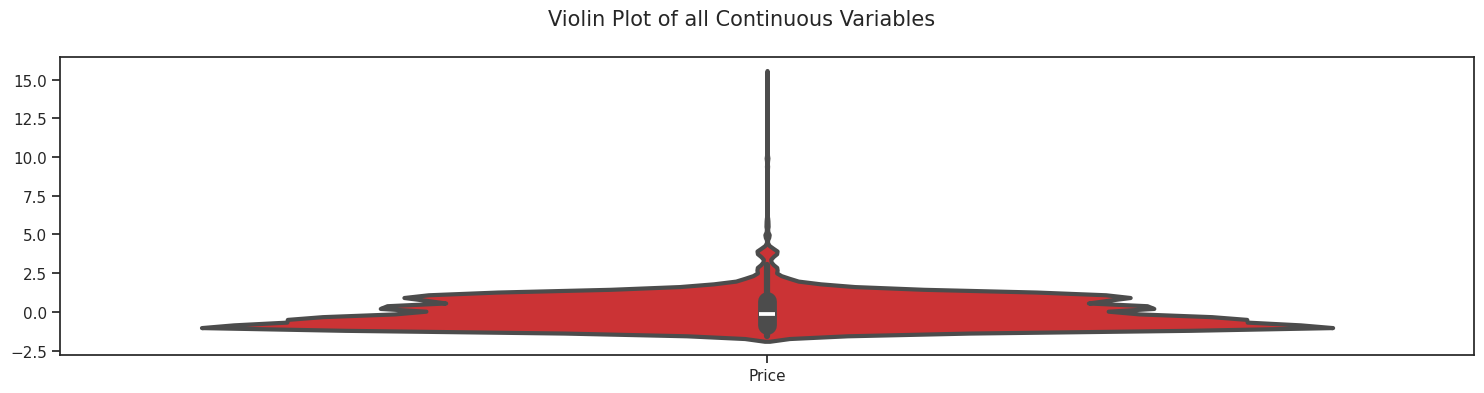

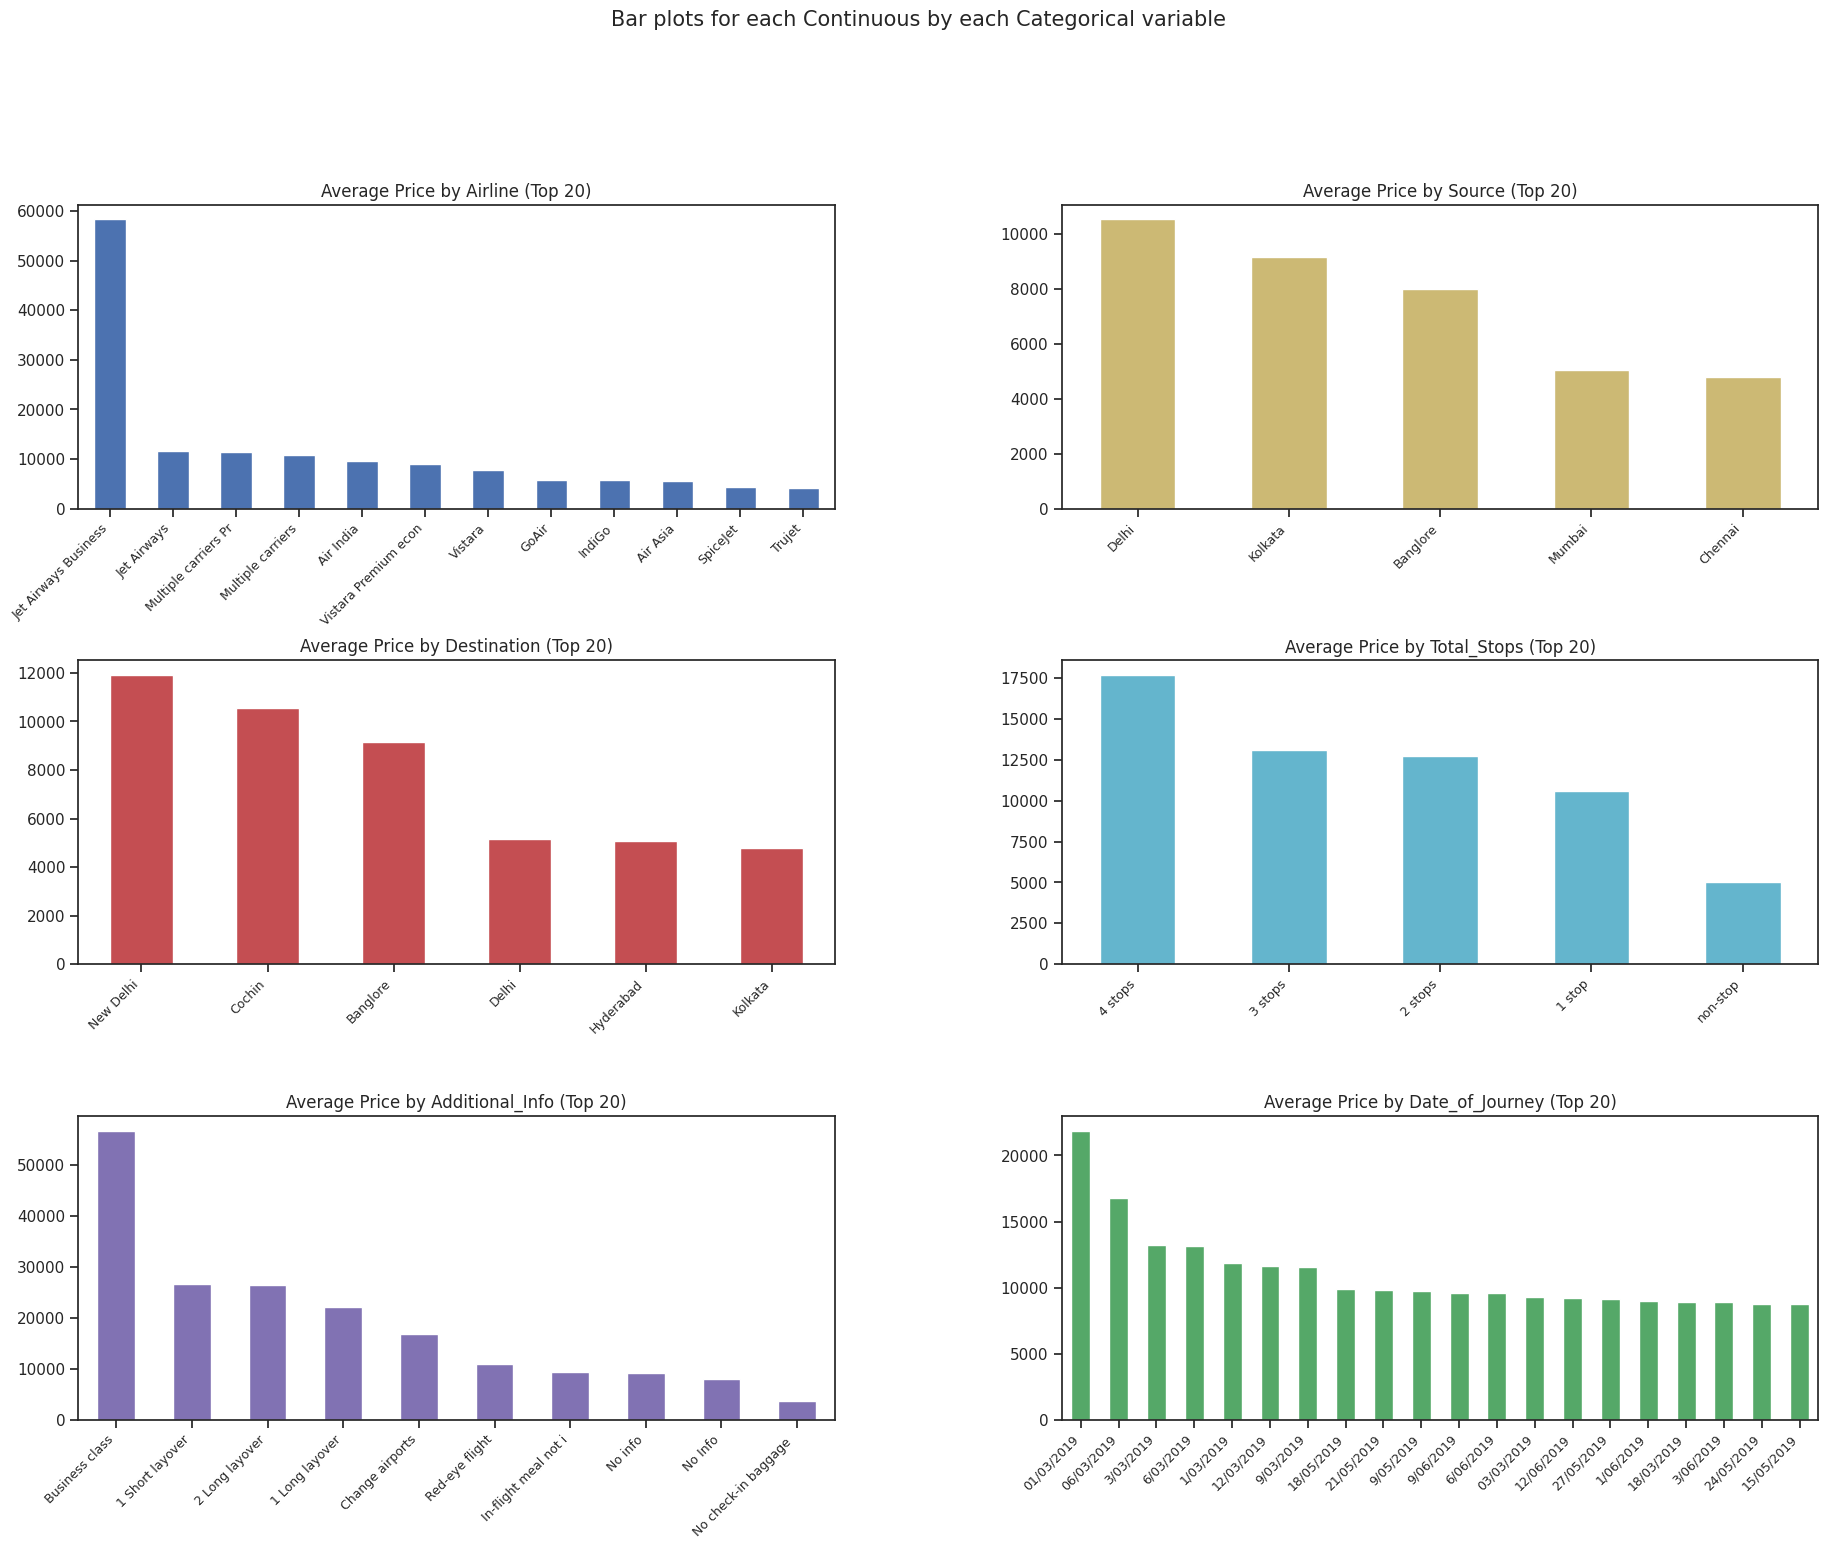

[nltk_data] Downloading collection 'popular'
[nltk_data]    | 
[nltk_data]    | Downloading package cmudict to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/cmudict.zip.
[nltk_data]    | Downloading package gazetteers to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/gazetteers.zip.
[nltk_data]    | Downloading package genesis to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/genesis.zip.
[nltk_data]    | Downloading package gutenberg to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/gutenberg.zip.
[nltk_data]    | Downloading package inaugural to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/inaugural.zip.
[nltk_data]    | Downloading package movie_reviews to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping corpora/movie_reviews.zip.
[nltk_data]    | Downloading package names to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/names.zip.
[nltk_data]    | Downloading package shakespeare to /root/nltk_data...
[nlt

Could not draw wordcloud plot for Arrival_Time. 
Looks like you are missing some required data for this feature.

To download the necessary data, simply run

    python -m textblob.download_corpora

or use the NLTK downloader to download the missing data: http://nltk.org/data.html
If this doesn't fix the problem, file an issue at https://github.com/sloria/TextBlob/issues.

Could not draw wordcloud plot for Route. 
Looks like you are missing some required data for this feature.

To download the necessary data, simply run

    python -m textblob.download_corpora

or use the NLTK downloader to download the missing data: http://nltk.org/data.html
If this doesn't fix the problem, file an issue at https://github.com/sloria/TextBlob/issues.

Could not draw wordcloud plot for Dep_Time. 
Looks like you are missing some required data for this feature.

To download the necessary data, simply run

    python -m textblob.download_corpora

or use the NLTK downloader to download the missing data: htt

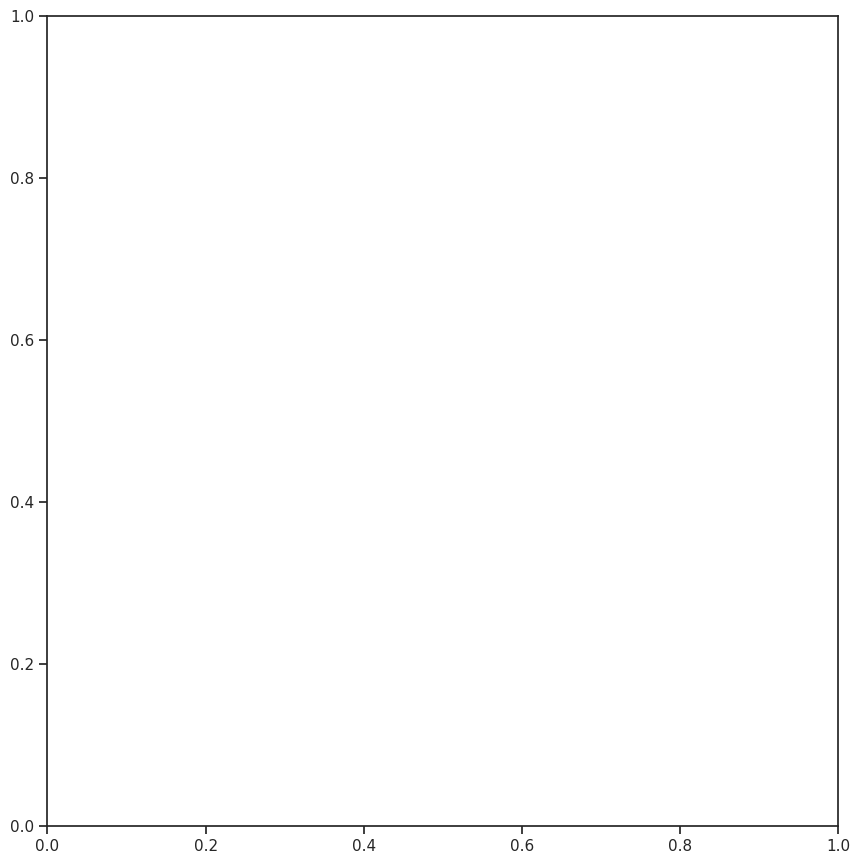

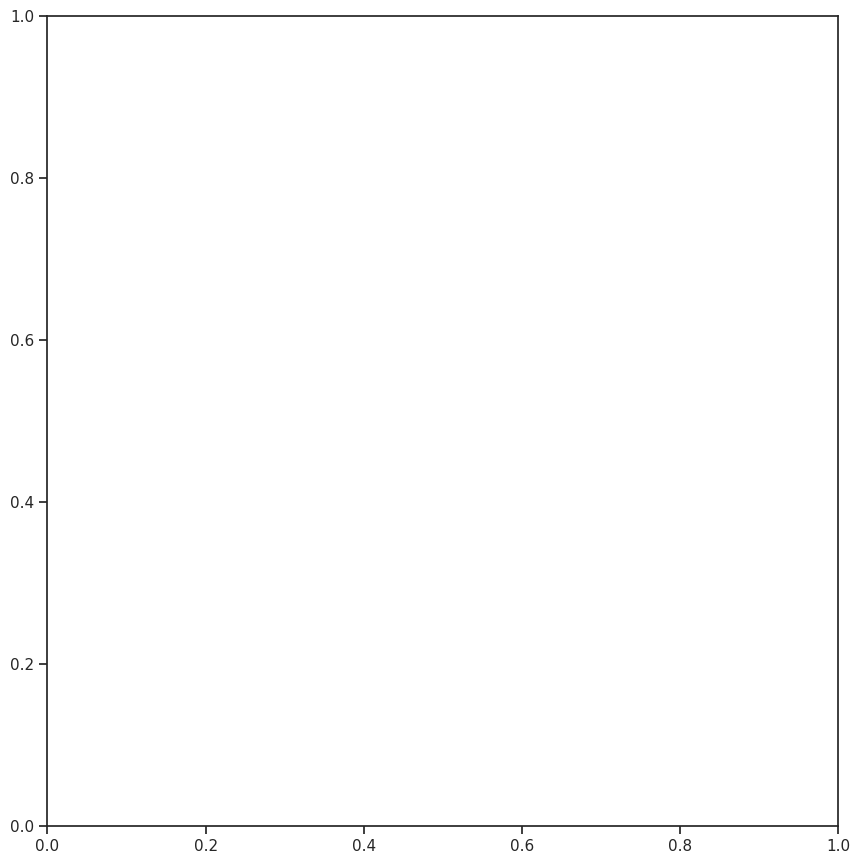

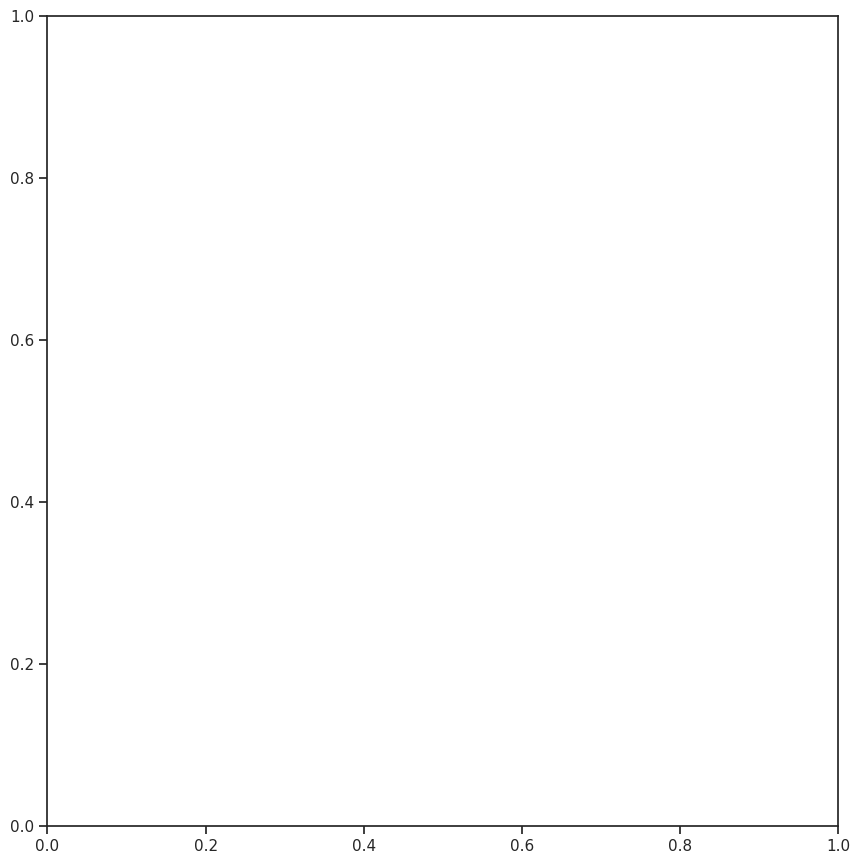

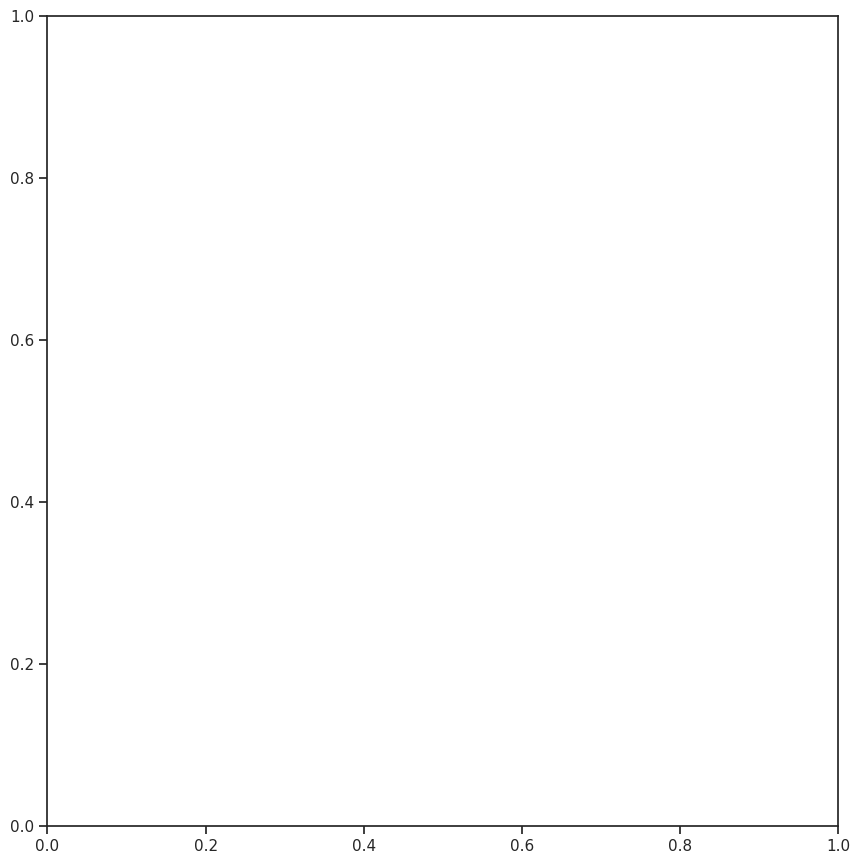

In [142]:
import matplotlib.pyplot as plt
%matplotlib INLINE
# Pass the DataFrame directly to AutoViz
nik=AV.AutoViz(
    '',
    dfte=df.copy() # Pass the DataFrame to dfte
)

In [156]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
def predict(ml_model):
    print('Model is: {}'.format(ml_model))
    model= ml_model.fit(x_train,y_train)
    print("Training score: {}".format(model.score(x_train,y_train)))
    predictions = model.predict(x_test)
    print("Predictions are: {}".format(predictions))
    print('\n')
    r2score=r2_score(y_test,predictions)
    print("r2 score is: {}".format(r2score))

    print('MAE:{}'.format(mean_absolute_error(y_test,predictions)))
    print('MSE:{}'.format(mean_squared_error(y_test,predictions)))
    print('RMSE:{}'.format(np.sqrt(mean_squared_error(y_test,predictions))))

    sns.distplot(y_test-predictions)

In [152]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor,RandomForestRegressor

Model is: RandomForestRegressor()
Training score: 0.7902770366058322
Predictions are: [ 4353.27511382  4280.3107905   3813.48358288 ... 11419.03816886
  9783.55316162  6238.27872943]


r2 score is: 0.6003390206602475
MAE:1676.3228625341496
MSE:8377624.891757087
RMSE:2894.412702390087


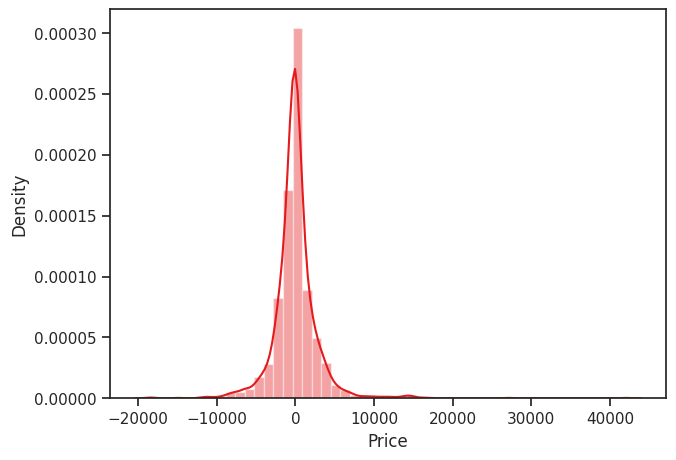

In [157]:
predict(RandomForestRegressor())

Model is: LogisticRegression()
Training score: 0.2720571027381231
Predictions are: [ 3597  3383  3100 ... 10262 10844  7229]


r2 score is: 0.3524205545514463
MAE:2151.5690219934486
MSE:13574449.250818904
RMSE:3684.35194448344


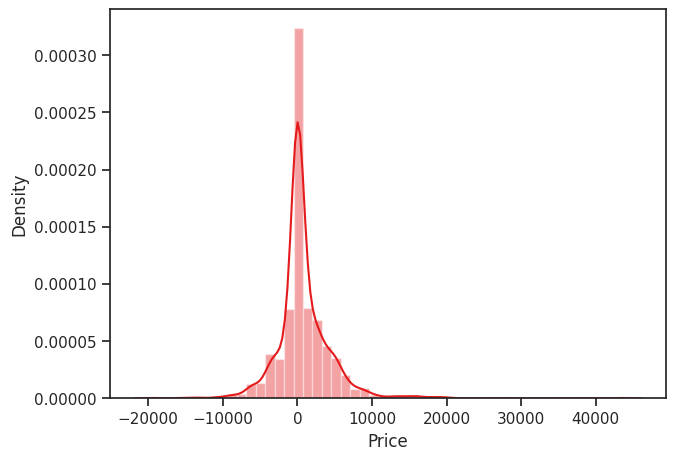

In [159]:
predict(LogisticRegression())

Model is: KNeighborsRegressor()
Training score: 0.7238654101771552
Predictions are: [ 4336.6  5317.8  3310.  ... 11274.4  9851.8  6822.8]


r2 score is: 0.6035466933186445
MAE:1694.8548432381842
MSE:8310386.207730465
RMSE:2882.774047290294


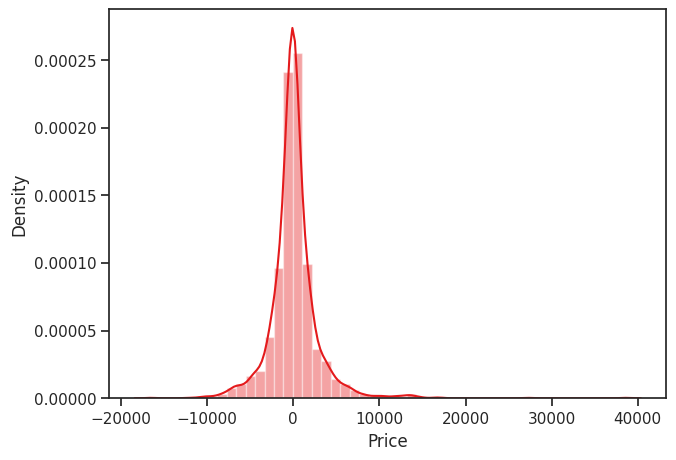

In [160]:
predict(KNeighborsRegressor())

Model is: DecisionTreeRegressor()
Training score: 0.7968232770023913
Predictions are: [ 4364.21052632  4321.26666667  3748.47058824 ... 11351.88888889
  9851.8         6232.26470588]


r2 score is: 0.5461468512888089
MAE:1739.3313823483395
MSE:9513591.850088868
RMSE:3084.4111026399946


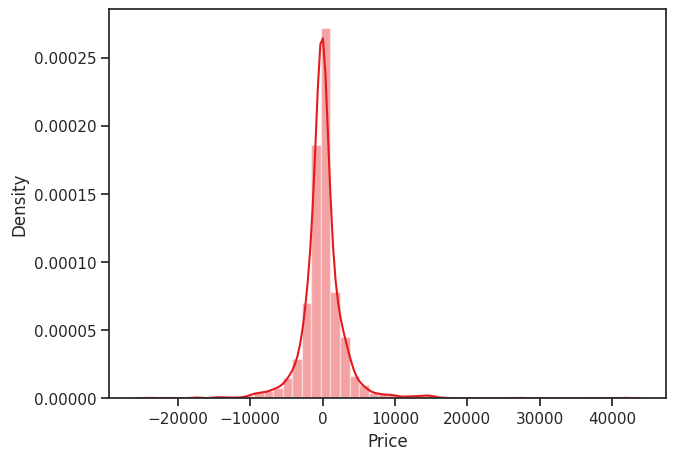

In [161]:
predict(DecisionTreeRegressor())

Model is: SVR()
Training score: 0.05288570076193888
Predictions are: [7853.54431882 7942.93562354 7921.48646167 ... 8883.52400821 8594.07732431
 8150.10327999]


r2 score is: 0.059326887329270495
MAE:3359.7850904663487
MSE:19718228.426342327
RMSE:4440.52118859288


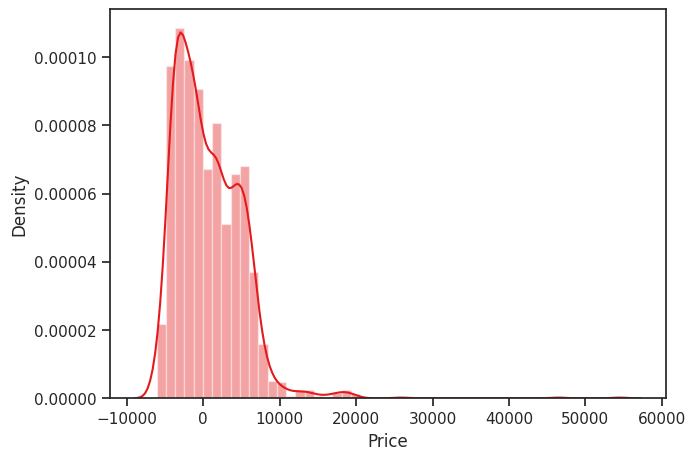

In [162]:
from sklearn.svm import SVR
predict(SVR())

Model is: GradientBoostingRegressor()
Training score: 0.6223481108254754
Predictions are: [ 4005.59089942  4710.41697246  6940.62565552 ... 12271.69270991
 11964.14858797  6275.37775502]


r2 score is: 0.5745926225107733
MAE:2015.040391723894
MSE:8917316.473273136
RMSE:2986.187615216622


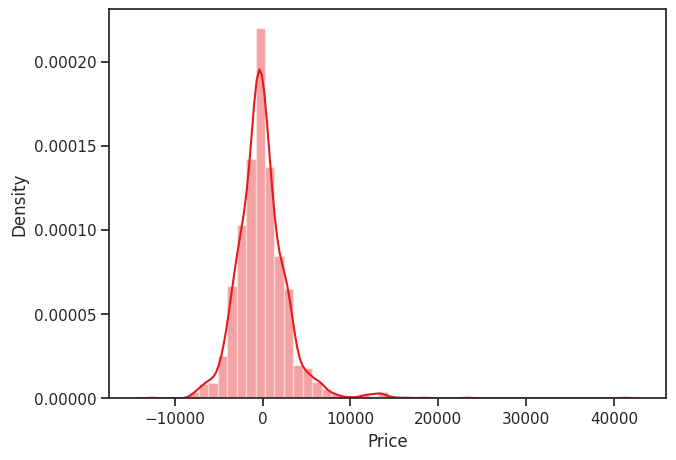

In [163]:
predict(GradientBoostingRegressor())

In [164]:
from sklearn.model_selection import RandomizedSearchCV

In [165]:
random_grid = {
    'n_estimators' : [100, 120, 150, 180, 200,220],
    'max_features':['auto','sqrt'],
    'max_depth':[5,10,15,20],
    }

In [168]:
rf=RandomForestRegressor()
rf_random=RandomizedSearchCV(estimator=rf,param_distributions=random_grid,cv=3,verbose=2,n_jobs=-1,)

rf_random.fit(x_train,y_train)

rf_random.best_params_

Fitting 3 folds for each of 10 candidates, totalling 30 fits


{'n_estimators': 180, 'max_features': 'sqrt', 'max_depth': 10}

In [169]:
rf_random.best_params_

{'n_estimators': 180, 'max_features': 'sqrt', 'max_depth': 10}

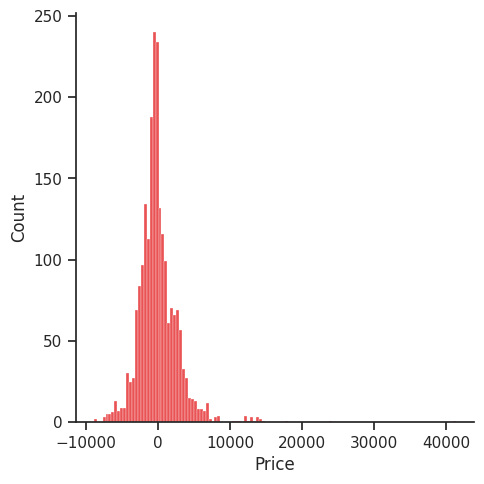

In [171]:
prediction = rf_random.predict(x_test)

#distribution plot between actual value and predicted value
sns.displot(y_test-prediction)

In [172]:
r2_score(y_test,prediction)

0.6170127888231666